# 06: Can It Make Another One?

This chapter notebook is intentionally cautious: the source figures are explanatory/conceptual, so the executable work demonstrates detectors and lineage bookkeeping rather than claiming empirical Evoloops or Outlier evidence.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
EXPERIMENT = {"pattern": [[0,1,1,0],[1,1,1,1],[0,1,0,0]], "lineage_descendants": [1,1,2,2,3,4,5,7,9,12,16,21,28]}
EXPERIMENT


{'pattern': [[0, 1, 1, 0], [1, 1, 1, 1], [0, 1, 0, 0]],
 'lineage_descendants': [1, 1, 2, 2, 3, 4, 5, 7, 9, 12, 16, 21, 28]}

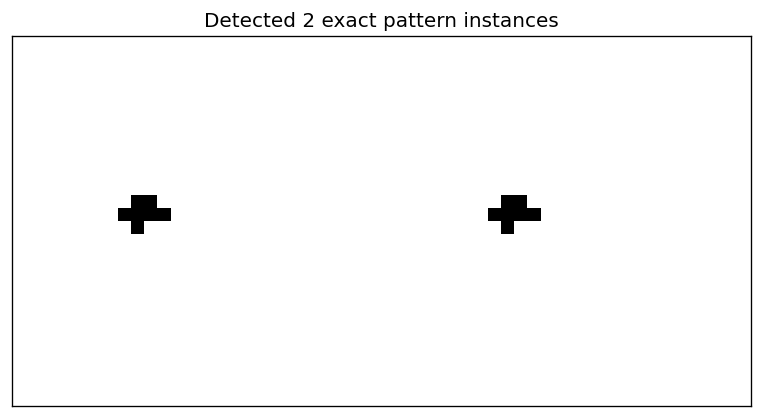

[(12, 8), (12, 36)]

In [3]:
parent = np.array(EXPERIMENT["pattern"], dtype=np.uint8)
def stamp(canvas, pattern, row, col): canvas[row:row+pattern.shape[0], col:col+pattern.shape[1]] = pattern
def find_exact_pattern(world, pattern):
    hits=[]; h,w = pattern.shape
    for r in range(world.shape[0]-h+1):
        for c in range(world.shape[1]-w+1):
            if np.array_equal(world[r:r+h, c:c+w], pattern): hits.append((r,c))
    return hits
world = np.zeros((28,56), dtype=np.uint8); stamp(world, parent, 12, 8); stamp(world, parent, 12, 36)
hits = find_exact_pattern(world, parent)
fig, ax = plt.subplots(figsize=(8,4)); ax.imshow(world, cmap="binary", interpolation="nearest"); ax.set(title=f"Detected {len(hits)} exact pattern instances", xticks=[], yticks=[]); plt.show(); hits


## Measurement example: lineage counts


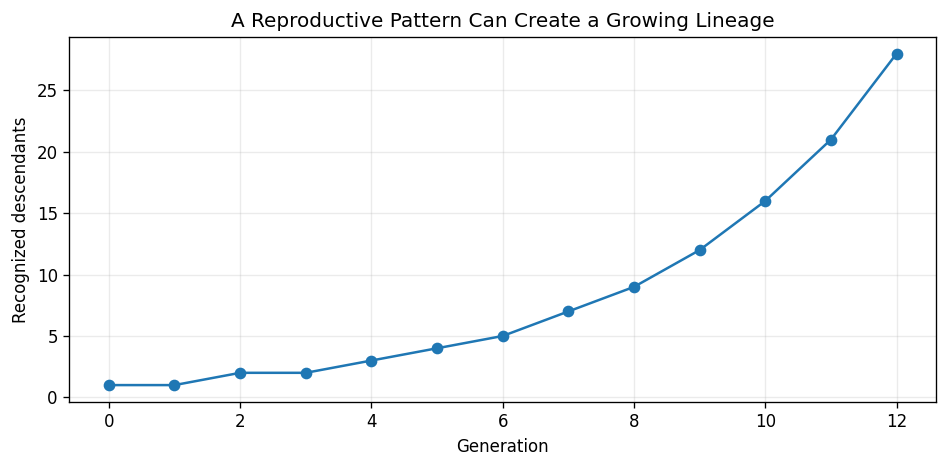

{'initial': 1, 'final': 28, 'growth_factor': 28.0}

In [4]:
generations = np.arange(len(EXPERIMENT["lineage_descendants"])); descendants = np.array(EXPERIMENT["lineage_descendants"])
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(generations, descendants, marker="o"); ax.set(title="A Reproductive Pattern Can Create a Growing Lineage", xlabel="Generation", ylabel="Recognized descendants"); ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(FIG_DIR / "ch06-lineage-growth.png", bbox_inches="tight"); plt.show()
{"initial": int(descendants[0]), "final": int(descendants[-1]), "growth_factor": float(descendants[-1]/descendants[0])}


## Control logic

A detector finding two similar patterns is not enough for parenthood. A causal reproduction test would compare a parent-present run against a parent-removed or parent-perturbed run and measure whether the second instance is prevented, delayed, or changed.

## What the evidence supports

The notebook supports the operational distinction among copying, similarity, distinct instances, lineage counts, and causal reproduction tests. It does not claim that this toy sequence is Evoloops, Outlier, or empirical self-reproduction.

## Provenance

**Book chapter**

`content/books/digital-life/06-can-it-make-another-one/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch06_can_it_make_another_one.py`

**Book figures reproduced**

- `static/images/books/digital-life/ch06-lineage-growth.png`

The source script marks the replication GIF and lineage curve as explanatory/conceptual; this notebook preserves that limitation.
